In [1]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
# import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm

In [2]:
# 概率比较部分
from scipy.special import gammaln
# import torch.distributions as dist

# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation

import os
import glob
import re

Trans into torch tensor input


In [3]:
from importlib import reload  
  
reload(DE)
from DE import DESimulation

In [4]:
cevns_file = np.load('sim_result/cevns_pattern.npz')
DE_file = np.load('sim_result/DE_pattern.npz')

cevns_info = np.zeros(len(cevns_file['cevns_area']),dtype = np.dtype([('area', '<f8'),('st_cor', '<f8'),('pattern', '<f8'),('e_num','uint32')]))
cevns_info['area'] = cevns_file['cevns_area']
cevns_info['st_cor'] = cevns_file['cevns_st_cor']
cevns_info['pattern'] = cevns_file['cevns_pattern_coefficient']
cevns_info['e_num'] = cevns_file['cevns_e_num']

DE_info = np.zeros(len(DE_file['DE_area']),dtype = np.dtype([('area', '<f8'),('st_cor', '<f8'),('pattern', '<f8'),('e_num','uint32')]))
DE_info['area'] = DE_file['DE_area']
DE_info['st_cor'] = DE_file['DE_st_cor']
DE_info['pattern'] = DE_file['DE_pattern_coefficient']
DE_info['e_num'] = DE_file['DE_e_num']

针对不同面积区域分bin
=======

  0%|                                                                                                                                              | 0/18 [00:00<?, ?it/s]

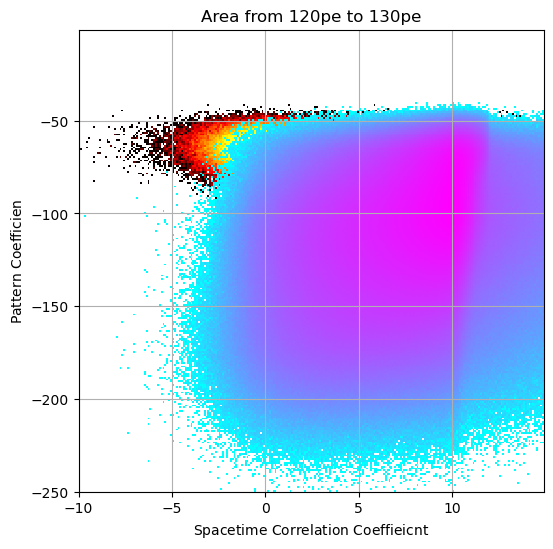

Area range from 120 to 130, DE_num: 56007310



  6%|███████▍                                                                                                                              | 1/18 [01:20<22:48, 80.52s/it]

[7.0499999999999945, -65.03476097435558] 0.2153907283898319


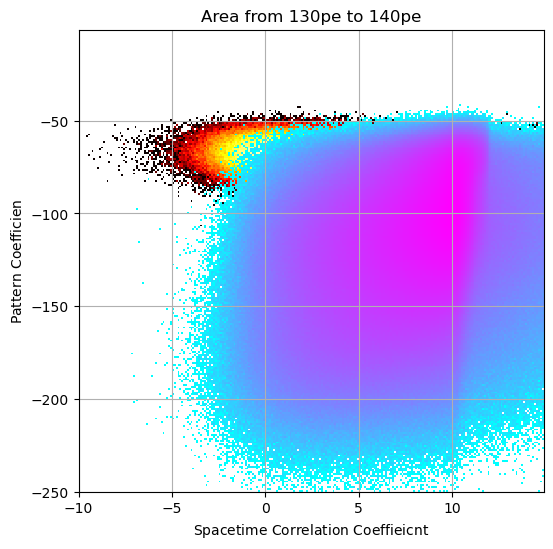

Area range from 130 to 140, DE_num: 25358081



 11%|██████████████▉                                                                                                                       | 2/18 [02:05<15:58, 59.89s/it]

[6.099999999999998, -71.45731305314726] 0.2919554617690964


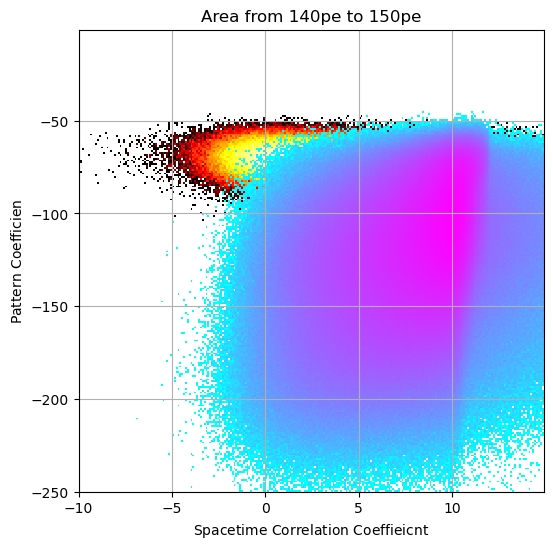

Area range from 140 to 150, DE_num: 11611629



 17%|██████████████████████▎                                                                                                               | 3/18 [02:33<11:13, 44.90s/it]

[5.949999999999998, -77.19954759402935] 0.36184264388832793


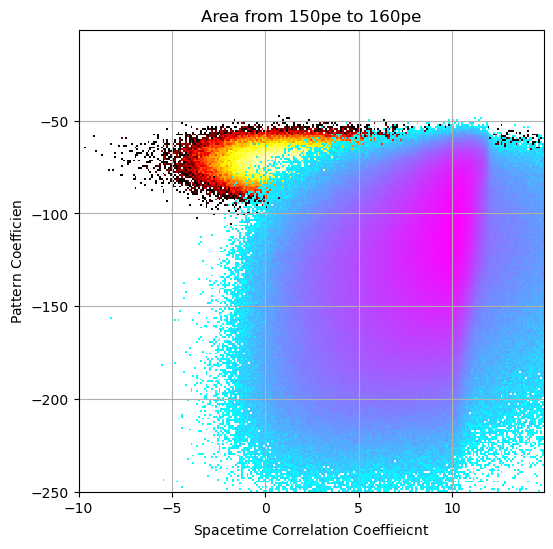

Area range from 150 to 160, DE_num: 5458462



 22%|█████████████████████████████▊                                                                                                        | 4/18 [02:49<07:53, 33.79s/it]

[5.699999999999999, -83.6742645576435] 0.4551792052482802


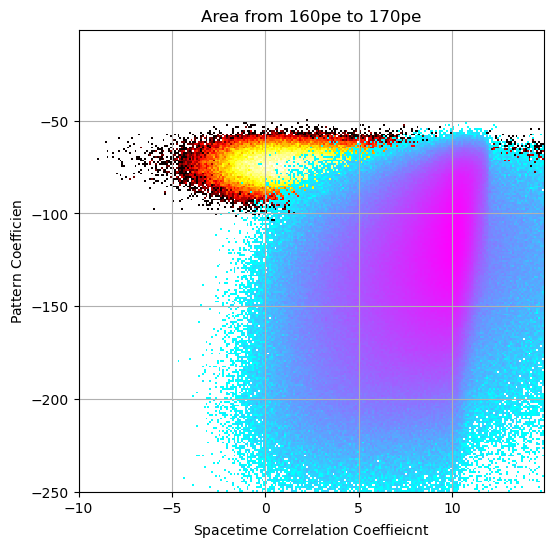

Area range from 160 to 170, DE_num: 2602451



 28%|█████████████████████████████████████▏                                                                                                | 5/18 [03:01<05:35, 25.82s/it]

[5.5, -89.16284245646712] 0.5356185041040968


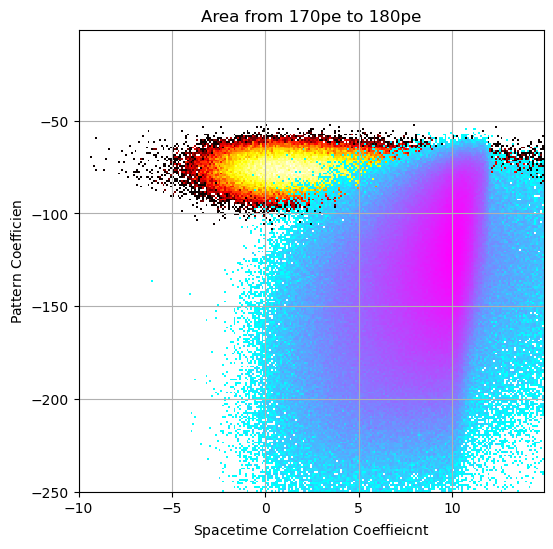

Area range from 170 to 180, DE_num: 1247604



 33%|████████████████████████████████████████████▋                                                                                         | 6/18 [03:10<04:00, 20.03s/it]

[5.949999999999998, -96.45702925876066] 0.6081222524597028


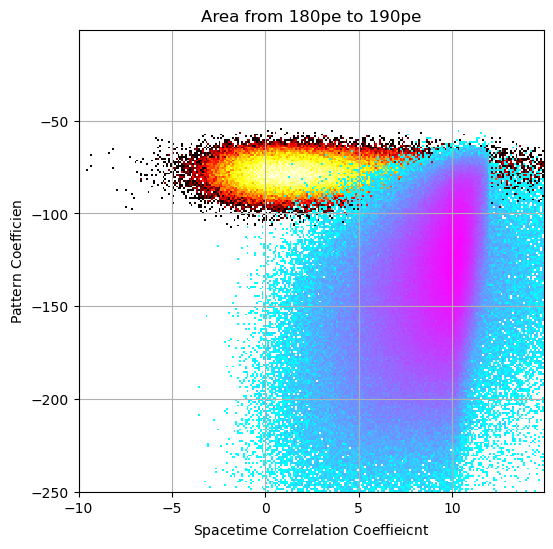

Area range from 180 to 190, DE_num: 602641



 39%|████████████████████████████████████████████████████                                                                                  | 7/18 [03:17<02:55, 15.93s/it]

[5.749999999999999, -101.25842102633558] 0.6701680357917733


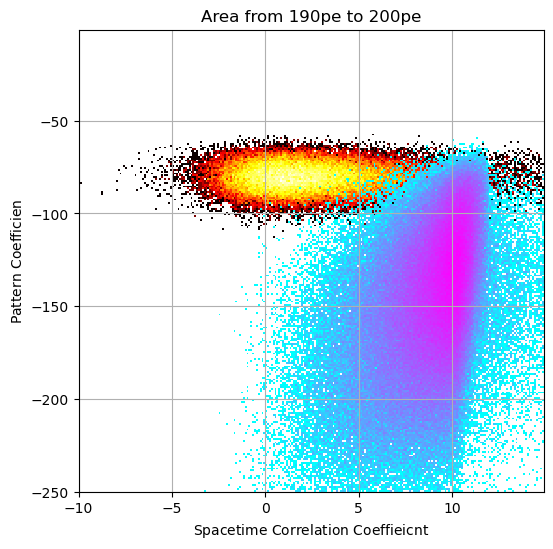

Area range from 190 to 200, DE_num: 295773



 44%|███████████████████████████████████████████████████████████▌                                                                          | 8/18 [03:25<02:13, 13.39s/it]

[5.749999999999999, -106.56086532804724] 0.7212049730273207


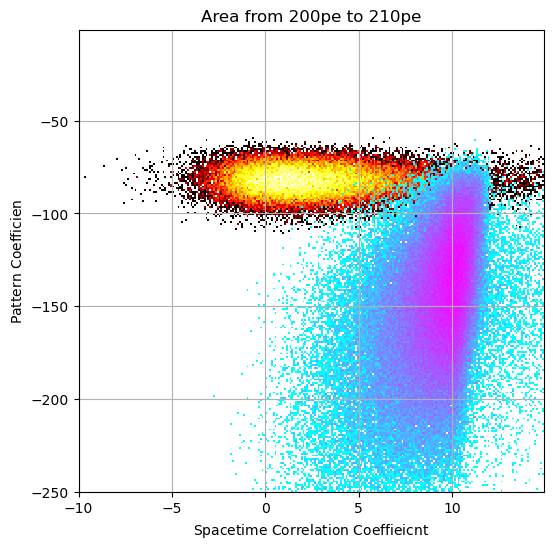

Area range from 200 to 210, DE_num: 146301



 50%|███████████████████████████████████████████████████████████████████                                                                   | 9/18 [03:33<01:44, 11.59s/it]

[5.55, -110.7625573135308] 0.761954261954262


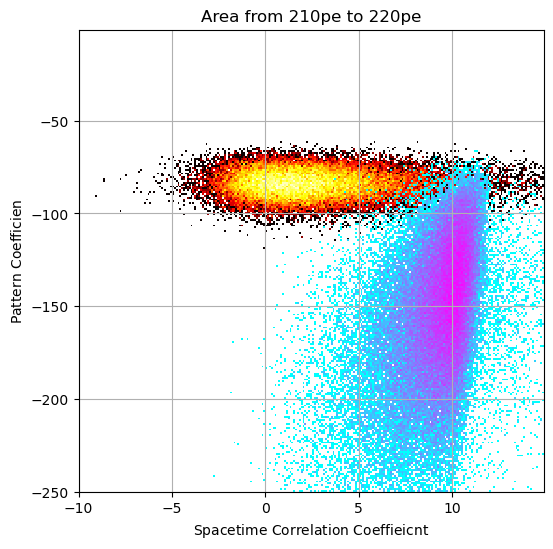

Area range from 210 to 220, DE_num: 72460



 56%|█████████████████████████████████████████████████████████████████████████▉                                                           | 10/18 [03:40<01:22, 10.34s/it]

[5.749999999999999, -116.55796676505962] 0.7958742949234489


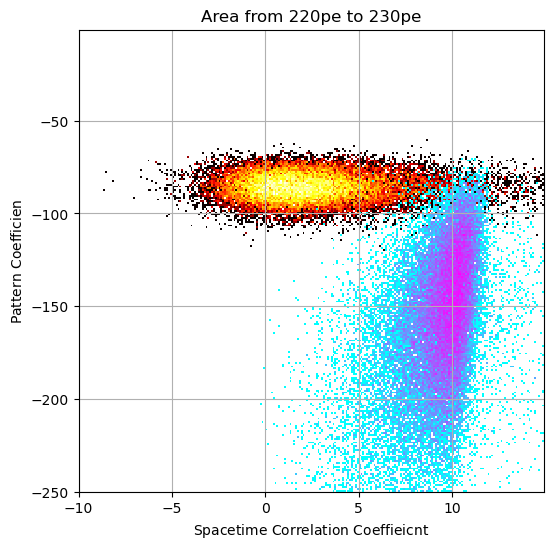

Area range from 220 to 230, DE_num: 36178



 61%|█████████████████████████████████████████████████████████████████████████████████▎                                                   | 11/18 [03:49<01:07,  9.69s/it]

[7.449999999999993, -124.76092983059094] 0.7818779381786413


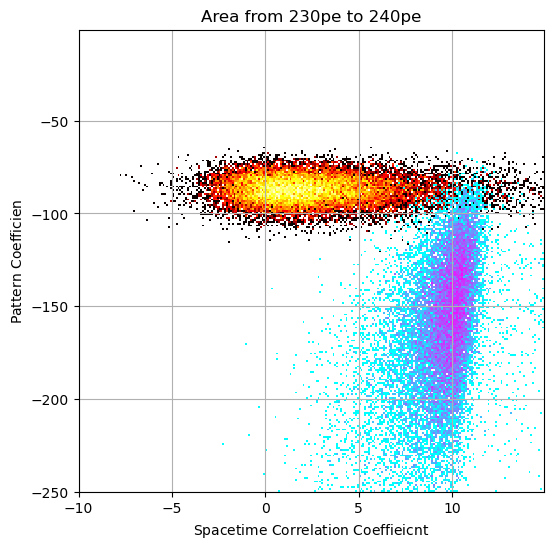

Area range from 230 to 240, DE_num: 18383



 67%|████████████████████████████████████████████████████████████████████████████████████████▋                                            | 12/18 [03:56<00:54,  9.03s/it]

[7.449999999999993, -135.72455524165284] 0.8447789776051917


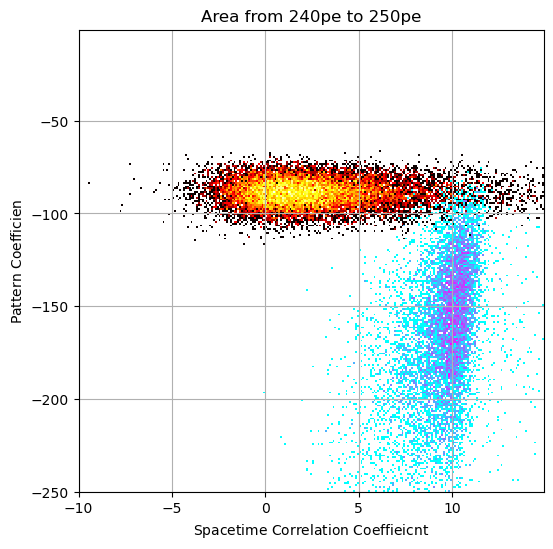

Area range from 240 to 250, DE_num: 8980



 72%|████████████████████████████████████████████████████████████████████████████████████████████████                                     | 13/18 [04:03<00:41,  8.36s/it]

[7.349999999999993, -146.40116384503915] 0.8941103190532217


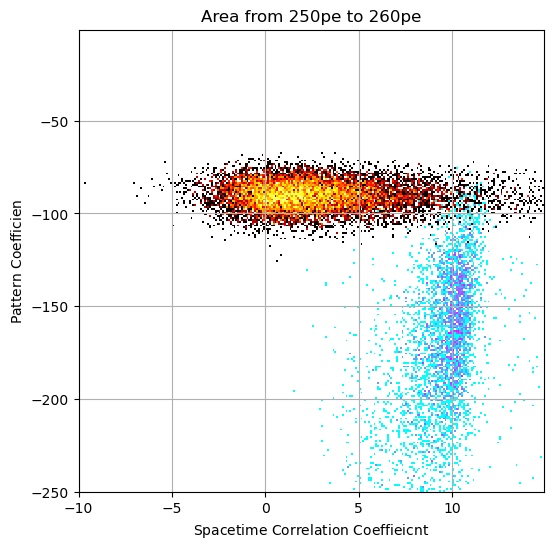

Area range from 250 to 260, DE_num: 4272



 78%|███████████████████████████████████████████████████████████████████████████████████████████████████████▍                             | 14/18 [04:10<00:31,  7.84s/it]

[5.5, -131.36318196665948] 0.8753604902667628


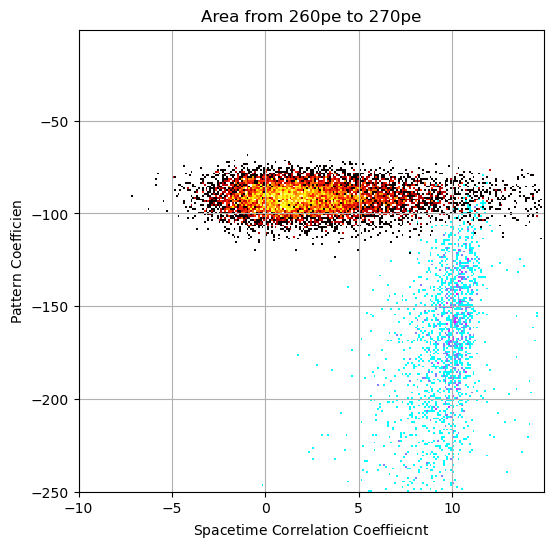

Area range from 260 to 270, DE_num: 1895



 83%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                      | 15/18 [04:17<00:23,  7.74s/it]

[7.449999999999993, -152.91299726782017] 0.9144303201506592


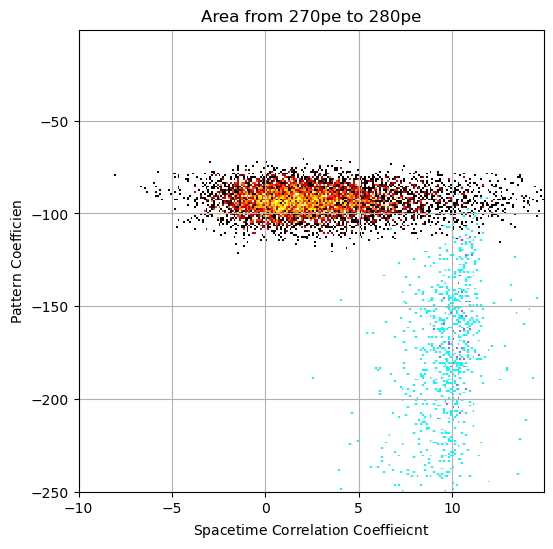

Area range from 270 to 280, DE_num: 822



 89%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏              | 16/18 [04:24<00:15,  7.63s/it]

[6.049999999999998, -149.2866961288189] 0.9360902255639098


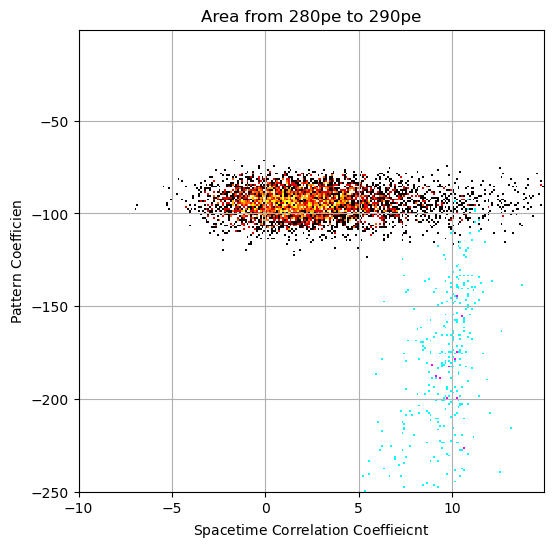

Area range from 280 to 290, DE_num: 352



 94%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌       | 17/18 [04:32<00:07,  7.67s/it]

[6.449999999999997, -159.299352540046] 0.9507992526468757


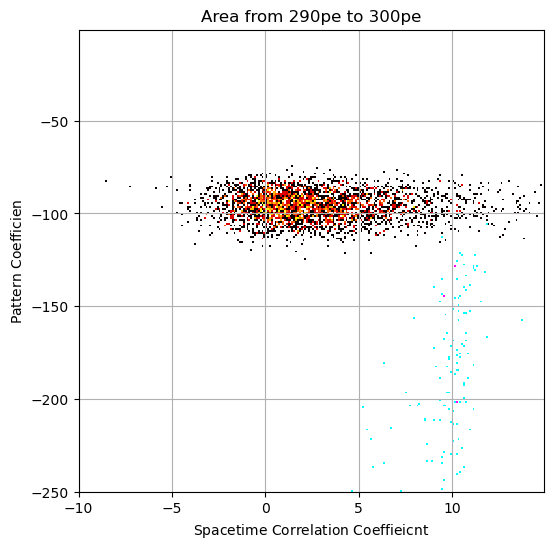

Area range from 290 to 300, DE_num: 137



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [04:40<00:00, 15.56s/it]

[5.6499999999999995, -159.20847753501363] 0.9670685092619817


In [7]:
area_range = np.arange(120,300,10)
area_central = []
k_st_max_exposure = []
b_max_exposure = []
exposure_area = []
k_st_list = np.arange(5.5,7.5,0.05)
x_bins = np.arange(-10,15,0.1)
y_bins = np.arange(-250,-0,1)
DE_remain = []

for i in tqdm(range(len(area_range))):
    area_low = area_range[i]
    area_high = area_range[i] + 10
    DE_pe_mask = (DE_info['area'] > area_low) & (DE_info['area'] < area_high)
    cevns_pe_mask = (cevns_info['area'] > area_low) & (cevns_info['area'] < area_high)
    
    cevns_bins = cevns_info[cevns_pe_mask]
    DE_bins = DE_info[DE_pe_mask]

    plt.figure(figsize=(6,6))  # 调整 figsize 参数以设置合适的宽度和高度
    H = plt.hist2d(cevns_bins['st_cor'], cevns_bins['pattern'], 
                   bins = [x_bins, y_bins], norm=LogNorm(), 
                   alpha = 1,label = 'CEvNS Event', cmap = 'hot')
    H = plt.hist2d(DE_bins['st_cor'], DE_bins['pattern'], 
                   bins = [x_bins, y_bins], norm=LogNorm(), 
                   alpha = 1,label = 'DE Event', cmap = 'cool')
    plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
    plt.ylabel(r'$\mathrm{Pattern\ Coefficien}$')
    plt.title('Area from {}pe to {}pe'.format(area_low, area_high))
    plt.grid()
    plt.show()
    
    print('Area range from {} to {}, DE_num: {}'.format(area_low, area_high, len(DE_info[DE_pe_mask])))
    DE_remain.append(len(DE_info[DE_pe_mask]) * 0.005 * 0.01)
    exposure = []
    k_list = []
    score_cevns = 0

    for k_st in tqdm(k_st_list):
        score_cevns = cevns_bins['pattern'] - (k_st * cevns_bins['st_cor']) 
        score_DE = DE_bins['pattern'] - (k_st * DE_bins['st_cor'])
        b = np.percentile(score_DE, 100-0.005)
        k_list.append([k_st,b])
        exposure.append(len(score_cevns[score_cevns>b])/len(score_cevns))
    exposure = np.array(exposure)

    # 找到最大值的索引
    index_of_max = np.argmax(exposure)
    print(k_list[index_of_max],np.max(exposure))
    k_st_area, b_area = k_list[index_of_max]
    area_central.append((area_low+area_high)/2)
    k_st_max_exposure.append(k_st_area)
    b_max_exposure.append(b_area)
    exposure_area.append(np.max(exposure))

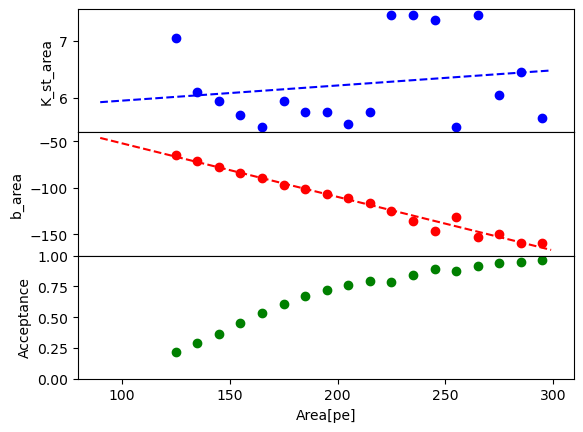

In [9]:
area_range = np.arange(90,300,1)

k_st_coefficients = np.polyfit(area_central, k_st_max_exposure, deg=1)  
k_st_fit = area_range * k_st_coefficients[0] + k_st_coefficients[1] 

b_coefficients = np.polyfit(area_central, b_max_exposure, deg=1)  
b_fit = area_range * b_coefficients[0] + b_coefficients[1] 

np.savez('k_st_coefficients', k_st_coefficients)
np.savez('b_coefficients', b_coefficients)

# 创建包含三个子图的图形，并设置它们之间的间距为0  
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, gridspec_kw={'hspace': 0})  
  
# 绘制第一个子图  
ax1.scatter(area_central, k_st_max_exposure, color = 'b')  
ax1.plot(area_range, k_st_fit, 'b--')
ax1.set_ylabel('K_st_area')  
  
# 绘制第二个子图，并移除x轴刻度标签以避免重复  
ax2.scatter(area_central, b_max_exposure,  color = 'r')  
ax2.plot(area_range, b_fit,'r--')
ax2.set_ylabel('b_area')  
ax2.tick_params(axis='x', labelbottom=False)  
  
# 绘制第三个子图  
ax3.scatter(area_central, exposure_area,  color = 'g')  
ax3.set_ylabel('Acceptance')  
ax3.set_xlabel('Area[pe]')  # 只在最后一个子图上设置x轴标签  
ax3.set_ylim(0,1)
# 设置标题（可选）  
plt.suptitle('')  
plt.savefig('figure/param_120_300.png')
# 显示图形  
plt.show()

In [10]:
score_cevns = cevns_info['pattern'] - ((cevns_info['area'] * k_st_coefficients[0] + k_st_coefficients[1] ) * cevns_info['st_cor']) 
b_cevns = cevns_info['area'] * b_coefficients[0] + b_coefficients[1] 

score_DE = DE_info['pattern'] - ((DE_info['area'] * k_st_coefficients[0] + k_st_coefficients[1] ) * DE_info['st_cor']) 
b_DE = DE_info['area'] * b_coefficients[0] + b_coefficients[1] 

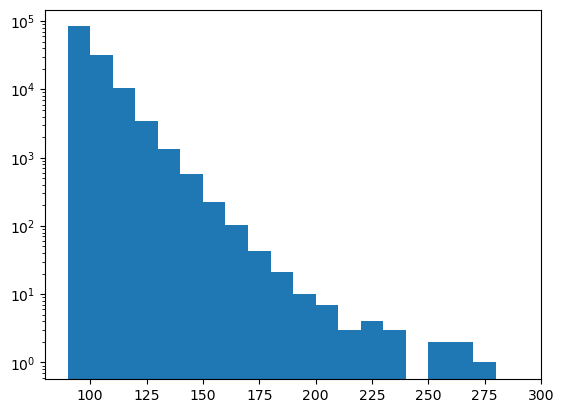

In [11]:
DE_pattern_cut_mask = score_DE > b_DE
CEvNS_survival_mask = score_cevns > b_cevns
# DE_strange_mask = (DE_info['area'] > 225) & (DE_info['area'] < 275)
plt.hist(DE_info[DE_pattern_cut_mask]['area'],bins = np.arange(90,300,10))
plt.yscale('log')
# plt.savefig('figure/DE_spectrum_120_300.png')
plt.show()

In [12]:
# 计算 Pattern cut 对于120-300PE ROI的rejection 和 acceptance
DE_roi_mask = (DE_info['area'] > 120) & (DE_info['area'] < 300)
CEvNS_roi_mask = (cevns_info['area'] > 120) & (cevns_info['area'] < 300)

rejection = len(DE_info[DE_roi_mask * DE_pattern_cut_mask]) / len(DE_info[DE_roi_mask])
acceptance = len(cevns_info[CEvNS_roi_mask * CEvNS_survival_mask]) / len(cevns_info[CEvNS_roi_mask])

print('Cut rejection power: {}, acceptance: {}'.format(rejection, acceptance))

Cut rejection power: 5.533771658431839e-05, acceptance: 0.4428649580028953


In [13]:
time_length = 4.261571815718157 / 50 * 18459 * 5  # hour
DE_spectrum_original,bins_edge = np.histogram(DE_info[DE_pattern_cut_mask]['area'], bins=np.arange(90,301,10))
DE_rate = DE_spectrum_original / time_length * 24 / 32 / 10
DE_rate_error =  DE_spectrum_original**0.5 / time_length * 24 / 32 / 10

逐文件进行，生成相应的波形
======

In [21]:
# 根据电子时间以及单电子弥散生成对应peak波形
def waveform_gen(pe_info,sigma_se):
    pe_num = len(pe_info)
    se_signal_delay = np.random.normal(0,sigma_se,pe_num)
    pe_time = pe_info['e_time'] + se_signal_delay
    pe_time = pe_time - np.mean(pe_time)
    # print(pe_time)
    sample_index = pe_time / (4e-9)
    sample_index = sample_index.astype(int)
    # print(sample_index)
    waveform = np.zeros(3500)
    np.add.at(waveform,sample_index + 1750,pe_info['area']/6e6)
    # np.add.at(waveform,sample_index + 1750,1)
    # print(pe_info['area']/6e6)
    # fig = plt.figure(figsize=(7, 4))
    # plt.plot(waveform[1000:-1000])
    # plt.show()
    return waveform

In [5]:
def sim_list_files(path,N = 18459):
    files = glob.glob(os.path.join(path, '*.npz'))  # 获取所有匹配的文件路径名
    print(len(files))
    files = sorted(files, key=lambda x: int(re.match(r'(\d+)', os.path.basename(x)).group(1)))  # 提取文件名中的数值部分并以其为键进行排序
    # for file in files[:N]:
    #     print(file)
    return files

file_list = sim_list_files("/home/cchang/RELICS_DE_sim_/new_S2_pattern_sim/DE_result_0822")

18459


In [49]:
# 根据模拟的结果，对于pattern过阈的事件，生成波形并记录面积，电子数等信息

pile_up_pattern_coefficient_list = []
pile_up_area_list = []
pile_up_e_num_list = []
pile_up_sp_cor_list = []
file_index_list = []


sigma_se = 190e-9
for i in tqdm(range(len(file_list))):
    waveform_list = []
# for i in tqdm(range(100)):
    file = np.load(file_list[i])
    pile_up_pattern_coefficient_file = file['pile_up_pattern_coefficient']
    pile_up_area_file =  file["pile_up_area"]
    # area_pattern =  data_save["area_pattern"]
    pile_up_pe_info_file = file["pile_up_pe_info"]
    pile_up_e_num_file =  file["pile_up_e_num"]
    pile_up_sp_cor_file = file['pile_up_sp_cor']
    event_id_file = np.arange(len(pile_up_area_file))
    
    # score_DE_file = pile_up_pattern_coefficient_file - (k_st * pile_up_sp_cor_file) + k_area * pile_up_area_file - b
    score_DE_file = pile_up_pattern_coefficient_file - ((pile_up_area_file * k_st_coefficients[0] + k_st_coefficients[1] ) * pile_up_sp_cor_file) 
    b_DE_file = pile_up_area_file * b_coefficients[0] + b_coefficients[1] 
    
    event_id_remain_file = event_id_file[score_DE_file > b_DE_file]
    pile_up_pattern_coefficient_list.append(pile_up_pattern_coefficient_file[score_DE_file > b_DE_file])
    pile_up_area_list.append(pile_up_area_file[score_DE_file > b_DE_file])
    pile_up_e_num_list.append(pile_up_e_num_file[score_DE_file > b_DE_file])
    pile_up_sp_cor_list.append(pile_up_sp_cor_file[score_DE_file > b_DE_file])
    
    for event_id in event_id_remain_file:
        pe_info = pile_up_pe_info_file[pile_up_pe_info_file['event_id'] == event_id]
        # print(pe_info)
        # print("pile_up_e_num: ", pile_up_e_num_file[event_id])
        # print("pile_up_area: ", pile_up_area_file[event_id])
        waveform = waveform_gen(pe_info,sigma_se)
        waveform_list.append(waveform)
        file_index_list.append(i)
        # fig = plt.figure(figsize=(6,3))
        # plt.plot(waveform[875:-875])
        # plt.show()
    np.savez('waveform_after_pattern_cut/waveform_{}.npz'.format(i),
             pile_up_pattern_coefficient=pile_up_pattern_coefficient_file[score_DE_file > 0],
             pile_up_area=pile_up_area_file[score_DE_file > 0],
             pile_up_e_num_list=pile_up_e_num_file[score_DE_file > 0],
             pile_up_sp_cor = pile_up_sp_cor_file[score_DE_file > 0],
             pile_up_waveform = waveform_list,
            ) 
    # print(len(pile_up_pattern_coefficient_file), len(event_id_remain_file), len(event_id_remain_file)/len(pile_up_pattern_coefficient_file))
    del file

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18459/18459 [5:28:17<00:00,  1.07s/it]


读取已经处理好的波形
======

In [6]:
waveform_list_ = []
for i in tqdm(range(len(file_list))):
# for i in tqdm(range(10)):
    # print(len(np.load('waveform_after_pattern_cut/waveform_{}.npz'.format(i))['pile_up_waveform']))
    if len(np.load('waveform_after_pattern_cut/waveform_{}.npz'.format(i))['pile_up_waveform']) > 0:
        waveform_list_.append(np.load('waveform_after_pattern_cut/waveform_{}.npz'.format(i))['pile_up_waveform'])

waveform_array = np.concatenate(waveform_list_)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18459/18459 [07:28<00:00, 41.16it/s]


In [14]:
len(DE_info[DE_roi_mask * DE_pattern_cut_mask])

5726

In [15]:
waveform_area = np.sum(waveform_array,axis = 1)
len(waveform_array[waveform_area > 120])

5726

In [16]:
test_de_data = waveform_array.reshape(-1, 1, 3500)
test_de_labels = np.zeros(len(test_de_data))
test_de_pe = np.sum(np.sum(test_de_data,axis = 1),axis = 1)

test_data = test_de_data.reshape(-1, 1, 3500)
test_labels = np.zeros(len(test_data))
test_pe = np.sum(np.sum(test_data,axis = 1),axis = 1)

In [17]:
import torch
import torch.nn as nn
import pickle
from PIL import Image
import h5py

#神经网络的结构，得跑一下才能把后面有些定义的变量弄进去，不耗时间
class WaveformClassifier(nn.Module):
    def __init__(self):
        super(WaveformClassifier, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)  # 使用全局平均池化层
        self.fc = nn.Sequential(
            nn.Linear(128, 64),  # 修改全连接层的输入维度
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 2)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x).squeeze(2)
        x = self.fc(x)
        return x
    

In [18]:
#把测试集的名字换成我们需要的，test_filename = 'test3.pkl'，这个。然后用已经做好的模型model.load_state_dict(torch.load('waveform_classifier.pth'))得到一个分数
#这个分数存在h5_filename = 'scores3.h5'这里面

# # 加载测试集数据和标签
# test_filename = 'test3.pkl'
# 长度为3500的波形？
# train_loss_values = []  # 保存训练损失值的列表
# test_loss_values = []   # 保存测试损失值的列表

# with open(test_filename, 'rb') as f:
#     test_data, test_labels, test_pe = pickle.load(f)



# # 转换数据通道数为1并调整大小
# test_data = test_data.reshape(-1, 1, 3500)

# 将测试集数据和标签转换为PyTorch张量
test_data = torch.from_numpy(test_data).float()
test_labels = torch.from_numpy(test_labels).long()

# 创建测试集数据集和数据加载器
test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# 加载模型
model = WaveformClassifier()
model.load_state_dict(torch.load('sim_config/waveform_classifier.pth'))


# 测试模式
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0
test_confusion_matrix = torch.zeros(2, 2)
criterion = nn.CrossEntropyLoss()

num_epochs = 2
with torch.no_grad():
    for batch_data, batch_labels in test_dataloader:
        outputs = model(batch_data)
        loss = criterion(outputs, batch_labels)
        test_loss += loss.item() * batch_data.size(0)

        # 计算测试集准确率和混淆矩阵
        _, predicted = torch.max(outputs, 1)
        test_total += batch_labels.size(0)
        test_correct += (predicted == batch_labels).sum().item()

        for i in range(len(predicted)):
            test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

# 计算平均测试集损失函数和准确率
test_loss /= len(test_dataset)
test_accuracy = test_correct / test_total

# 计算标签0判断为标签1和标签1判断为标签0的概率
test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


# 在测试集上进行评估
model.eval()
test_confusion_matrix = torch.zeros(2, 2)

# 在测试集上计算预测分数
with torch.no_grad():
    model.eval()
    outputs = model(test_data)
    scores = torch.softmax(outputs, dim=1)

# 绘制预测分数的分布
scores_label_0 = scores[test_labels == 0]
scores_label_1 = scores[test_labels == 1]


Test Loss: 0.5350, Test Accuracy: 0.7668
Test False Positive Rate: 0.2332, Test False Negative Rate: nan


/home/cchang/.conda/envs/geant4/lib/python3.8/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


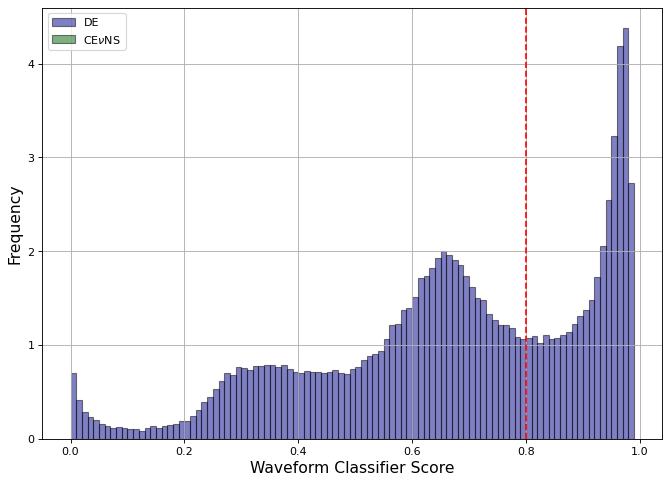

In [19]:
import matplotlib.pyplot as plt
# 创建一个新的图形并设置大小
fig= plt.figure(figsize=(10, 7),dpi = 80)
plt.hist(scores_label_0[:, 0].numpy(), bins=np.arange(0,1,0.01), edgecolor='black', alpha=0.5, label='DE', density=True, color='darkblue')
plt.hist(scores_label_1[:, 0].numpy(), bins=np.arange(0,1,0.01), edgecolor='black', alpha=0.5, label=r"CE$\nu$NS", density=True, color='darkgreen')

plt.xlabel('Waveform Classifier Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
#plt.title('Distribution of Prediction Scores')
plt.legend()
# plt.savefig('defen.svg', transparent=True, dpi=400, bbox_inches='tight')
plt.axvline(x=0.8, color='red', linestyle='dashed')
plt.grid()
plt.show()


# h5_filename = 'scores3.h5'
# h5_file = h5py.File(h5_filename, 'w')

# # 将得分存储为名为'scores'的数据集
# h5_file.create_dataset('scores', data=scores.numpy())

# # 关闭HDF5文件
# h5_file.close()


In [20]:
DE_waveform_score = scores_label_0[:, 0].numpy()

计算波形宽度，运用s2_width cut

In [21]:
sigma_array = ((np.arange(3500) - np.mean(np.arange(3500))) * 4)**2
time_array = (np.arange(3500) - np.mean(np.arange(3500))) * 4

def width_calculate(waveform,sigma_array):
    waveform_std = np.sum(waveform * sigma_array / np.sum(waveform))**0.5
    return waveform_std
width_list = []
for i in tqdm(range(len(waveform_array))):
    waveform = waveform_array[i]
    width_list.append(width_calculate(waveform,sigma_array))
width_array = np.array(width_list)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 131946/131946 [00:03<00:00, 40055.57it/s]


In [22]:
width_cut = width_array>220

In [23]:
len(waveform_array[width_cut*(DE_waveform_score>0.8)]) / len(waveform_array),len(waveform_array[DE_waveform_score < 0.8]) / len(waveform_array)

(0.20393949039758688, 0.649182241219893)

In [24]:
len(DE_info[DE_pattern_cut_mask][(DE_waveform_score>0.8) * width_cut])

26909

In [25]:
time_length = 4.261571815718157 / 50 * 18459 * 5  # hour
DE_spectrum_original,bins_edge_original = np.histogram(DE_info[DE_pattern_cut_mask]['area'], bins=np.arange(90,301,10))
DE_spectrum,bins_edge = np.histogram(DE_info[DE_pattern_cut_mask][(DE_waveform_score>0.8) * width_cut]['area'],
                                     bins=np.arange(90,301,10))
DE_rate_original = DE_spectrum_original / time_length * 24 / 32 / 10
DE_rate_error_original =  DE_spectrum_original**0.5 / time_length * 24 / 32 / 10

DE_rate = DE_spectrum / time_length * 24 / 32 / 10
DE_rate_error =  DE_spectrum**0.5 / time_length * 24 / 32 / 10

In [28]:
np.save("DE_rate_pattern", DE_rate_original)
np.save("DE_spectrum_pattern", DE_spectrum_original)
np.save("DE_rate_pattern_wf", DE_rate)
np.save("DE_spectrum_pattern_wf", DE_spectrum)

In [1]:
import numpy as np

In [3]:
DE_spectrum = np.load('DE_spectrum_pattern_wf.npy')

In [5]:
time_length = 4.261571815718157 / 50 * 18459 * 5  # hour
DE_rate = DE_spectrum / time_length * 24 / 32 / 10
DE_rate_error =  DE_spectrum**0.5 / time_length * 24 / 32 / 10

In [7]:
DE_rate

array([1.61690134e-01, 6.26967583e-02, 2.08226460e-02, 6.61671993e-03,
       2.59329657e-03, 1.25851157e-03, 5.62516536e-04, 1.81149393e-04,
       5.72050715e-05, 4.76708929e-05, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 9.53417858e-06, 0.00000000e+00,
       0.00000000e+00, 9.53417858e-06, 9.53417858e-06, 0.00000000e+00,
       0.00000000e+00])

In [6]:
DE_rate_error

array([1.24160486e-03, 7.73150755e-04, 4.45563492e-04, 2.51167254e-04,
       1.57241701e-04, 1.09539372e-04, 7.32334152e-05, 4.15585209e-05,
       2.33538726e-05, 2.13190714e-05, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 9.53417858e-06, 0.00000000e+00,
       0.00000000e+00, 9.53417858e-06, 9.53417858e-06, 0.00000000e+00,
       0.00000000e+00])

In [29]:
np.sum(DE_rate[3:]) * 365 * 10 * 32

1325.1745486408242

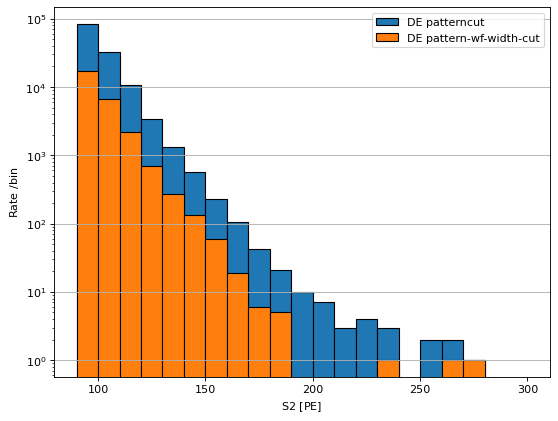

In [26]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=80)

# 创建一个柱状图并添加误差条
ax.bar((bins_edge_original[1:] + bins_edge_original[:-1])/2, DE_spectrum_original, edgecolor = "black", label = "DE patterncut",width=10,)
# ax.errorbar((bins_edge_original[1:] + bins_edge_original[:-1])/2, DE_rate_original, yerr=DE_rate_error_original, color = "black")


ax.bar((bins_edge[1:] + bins_edge[:-1])/2, DE_spectrum, edgecolor = "black", label = "DE pattern-wf-width-cut",width=10)
# ax.errorbar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate, yerr=DE_rate_error, color = "black")


ax.set_xlabel(r"$\mathrm{S2\ [PE]}$")
ax.set_ylabel(r"$\mathrm{Rate\ / bin}$")
ax.set_yscale("log")

# 设置y轴的刻度为每个10的n次方
# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
# ax.tick_params(direction='in')
# 增加背景刻度线
ax.grid(which='major', axis='y')

plt.legend()
plt.savefig("figure/DE_bins.png")

plt.show()

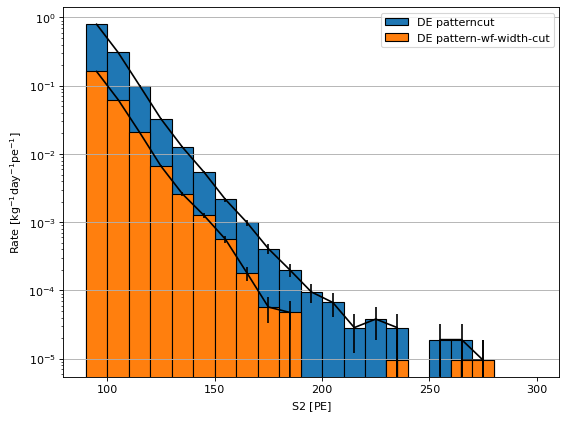

In [27]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=80)

# 创建一个柱状图并添加误差条
ax.bar((bins_edge_original[1:] + bins_edge_original[:-1])/2, DE_rate_original, edgecolor = "black", label = "DE patterncut",width=10,)
ax.errorbar((bins_edge_original[1:] + bins_edge_original[:-1])/2, DE_rate_original, yerr=DE_rate_error_original, color = "black")


ax.bar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate, edgecolor = "black", label = "DE pattern-wf-width-cut",width=10)
ax.errorbar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate, yerr=DE_rate_error, color = "black")


ax.set_xlabel(r"$\mathrm{S2\ [PE]}$")
ax.set_ylabel(r"$\mathrm{Rate\ [kg^{-1} day^{-1} pe^{-1}]}$")
ax.set_yscale("log")

# 设置y轴的刻度为每个10的n次方
# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
# ax.tick_params(direction='in')
# 增加背景刻度线
ax.grid(which='major', axis='y')

plt.legend()
plt.savefig("figure/DE_rate.png")

plt.show()

In [99]:
1e-5 * 32 * 10 * 365

1.1680000000000001

In [93]:
bins_edge

array([ 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210,
       220, 230, 240, 250, 260, 270, 280, 290, 300])

In [94]:
DE_rate

array([1.61690134e-01, 6.26967583e-02, 2.08226460e-02, 6.61671993e-03,
       2.59329657e-03, 1.25851157e-03, 5.62516536e-04, 1.81149393e-04,
       5.72050715e-05, 4.76708929e-05, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 9.53417858e-06, 0.00000000e+00,
       0.00000000e+00, 9.53417858e-06, 9.53417858e-06, 0.00000000e+00,
       0.00000000e+00])